In [1]:
# Relevant python functions
import pandas as pd
import numpy as np
import geopandas as gpd
import os
import sys
import matplotlib.pyplot as plt
import folium
from collections import Counter
import matplotlib.patches as mpatches
import contextily as ctx
from matplotlib.ticker import ScalarFormatter, MaxNLocator
from shapely.geometry import box
import matplotlib.lines as mlines


# Import functions for inventory generation 
parent_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
fxn_dir = os.path.join(parent_dir, "inventory_generation_functions")
sys.path.append(fxn_dir)
import functions_parcel_to_ftpt as inv_local 
import functions_general as fxns
import functions_inference as infr

In [2]:
# Set plotting CRS values for data manipulation and plotting
crs_main = '26910' # Used for data manipulation and storage
crs_plot = '4269' # Used for plotting 

# HAYWARD BOUNDS
xbounds = [-122.15, -122.02]
ybounds = [37.60, 37.69]


In [3]:
# Target Directory 
directory = './Inventory_Outputs/Synthesized_Local/'

# Make directory and intermediate directory
os.makedirs(directory, exist_ok=True)
dir_attribution = directory + 'FootprintAttribution/'
dir_intermediate = dir_attribution + 'Intermediate/'
os.makedirs(dir_intermediate, exist_ok=True)

# Figure Directory 
fig_dir = './Figures/General/'
os.makedirs(fig_dir, exist_ok=True)

## **Load Parcels**

In [4]:
# Load parcel geometry -- here, bring in extended 
parcels = fxns.json_to_gdf('./Input_Data/ProcessedData/Parcels_with_Extended_Data.json', crs_main)

## **Load Footprints and Tag with Possible APNs based on Geometry**

In [5]:
# Load building footprints 
footprints_original = fxns.json_to_gdf('./Input_Data/ProcessedFootprints/Hayward_Footprints.json', crs_main)

# Lower bound filters rows where the overlap is less than a given % of the footprint wiht a given parcel 
# Upper bound filters rows that have at least a given % of the footprint within a single parcel (drop other parcels associated with that footprint)
print(len(footprints_original))
footprints_filtered = inv_local.tag_ftpt_with_possible_apn(footprints_original, parcels, lower_bound=0, upper_bound=95)
print(len(footprints_filtered))

# Use these as footprints for merge
footprints = footprints_filtered.copy()

38355
50169


## **Update footprints to only include those with address data**

In [6]:
# Load address point data (attributed to footprints) 
points = fxns.json_to_gdf(dir_attribution + 'Address_Data_Attributed.json', crs_main)

# Filter for footprints that do/do not contain address points 
footprints_with_addresses = footprints[footprints['FootprintID'].isin(points['FootprintID'].to_list())]
footprints_no_addresses = footprints[~footprints['FootprintID'].isin(points['FootprintID'].to_list())]
print(len(footprints))
print(len(footprints_with_addresses))
print(len(footprints_no_addresses))


50169
44865
5304


In [7]:
# ## Plot footprints with no addresses

# ### UNCOMMENT CODE TO PLOT INTERACTIVE MAP WITH FOOTPRINTS AND NSI POINTS
# m = folium.Map(location=[parcels.copy().to_crs(crs_plot).geometry.iloc[0].centroid.y, parcels.copy().to_crs(crs_plot).geometry.iloc[0].centroid.x], zoom_start=12)

# # Create a base map
# # Add footprints (polygons)
# folium.GeoJson(footprints_with_addresses.copy().to_crs(crs_plot), color = 'gray').add_to(m)
# folium.GeoJson(footprints_no_addresses.copy().to_crs(crs_plot), color = 'red').add_to(m)
# # folium.GeoJson(parcels[parcels['Use_Description_Hazus'].isin(['RES4','RES5','RES6'])].copy().to_crs(crs_plot), color = 'blue').add_to(m)

# # display(m)


In [8]:
from IPython.display import display, HTML
def plot_help(m):
    data = m.get_root().render()
    data_fixed_height = data.replace('width: 100%;height: 100%', 'width: 100%').replace('height: 100.0%;', 'height: 609px;', 1)
    display(HTML(data_fixed_height))

## **Attribute Parcel Data to Footprints**

In [9]:
### MERGE ADDRESS POINTS WITH SCRAPED DATA ###

# Flag to determine if scaling is based on footprint area or building volumne 
use_height = True
new_ftpts_with_parcel = {}

counter = 0 
counter1 = 0 
unique_index = 0

# Record dropped parcels 
dropped_parcels = []

# Loop through parcels to populate dataframe 
print(len(parcels), 'parcels total (looping through these now)')
for index, row in parcels.iterrows():

    counter1 += 1
    if counter1 % 2000 == 0:
        print(counter1)


    # Get footprints within parcel 
    parcel_ftpt_address = footprints_with_addresses[footprints_with_addresses['APN_PQ']==row['APN_PQ']]
    parcel_ftpt_no_address = footprints_no_addresses[footprints_no_addresses['APN_PQ']==row['APN_PQ']]

    # ONE FOOTPRINT WITH ADDRESS DATA
    if len(parcel_ftpt_address) == 1: 

        # Associate all parcel data with given footprint 
        row['FootprintID'] = int(parcel_ftpt_address['FootprintID'].values[0])
        new_ftpts_with_parcel[unique_index] = row
        unique_index += 1
    



    # MULTIPLE FOOTPRINTS WITH ADDRESS DATA 
    elif len(parcel_ftpt_address) > 1:
            
        # Associate all parcel data with set of footprints 

        # Set all relevant footprint IDs to have parcel data associated with them
        for index, ftpt in parcel_ftpt_address.iterrows():
            cur_row = row.copy()
            cur_row['FootprintID'] = int(ftpt['FootprintID'])
            

            # Adjust scaling on various rows when splitting data across footprints
            if use_height: 
                num = ftpt['FootprintArea'] * ftpt['FootprintHeight'] # Volumne of each building
                denom = sum(parcel_ftpt_address['FootprintArea'] * parcel_ftpt_address['FootprintHeight']) # Summed volumne of everything in parcel
                factor = num / denom 
            else: 
                factor = ftpt['FootprintArea'] / sum(parcel_ftpt_address['FootprintArea'])

            # Assign scaling for area and value
            cur_row['Total_Value'] = cur_row['Total_Value'] * factor
            cur_row['Improvement_Value'] = cur_row['Improvement_Value'] * factor
            cur_row['Bldg_Area'] = cur_row['Bldg_Area'] * factor

            # Assign number of units - allow for 0 if original scrape has 0, but round to 1 in all other 0 cases 
            if cur_row['Num_Units'] > 0: 
                cur_row['Num_Units'] = max(np.round(cur_row['Num_Units'] * factor),1)

            # Assign number of buildings - allow for 0 if original scrape has 0, but round to 1 in all other 0 cases 
            if cur_row['Num_Bldg'] > 0: 
                cur_row['Num_Bldg'] = max(np.round(cur_row['Num_Bldg'] * factor),1)

            # Assign data to footprint 
            new_ftpts_with_parcel[unique_index] = cur_row.copy()
            unique_index += 1




    # ONE FOOTPRINT, BUT NO ADDRESS DATA 
    elif (len(parcel_ftpt_address) == 0) and len(parcel_ftpt_no_address) == 1 :

         # Associate all parcel data with given footprint 
        row['FootprintID'] = int(parcel_ftpt_no_address['FootprintID'].values[0])
        new_ftpts_with_parcel[unique_index] = row
        unique_index += 1





    # MULTIPLE FOOTPRINTS, BUT NO ADDRESS DATA 
    elif (len(parcel_ftpt_address) == 0) and len(parcel_ftpt_no_address) > 1 :

        # Associate all parcel data with set of footprints 

        # Set all relevant footprint IDs to have parcel data associated with them
        for index, ftpt in parcel_ftpt_no_address.iterrows():
            cur_row = row.copy()
            cur_row['FootprintID'] = int(ftpt['FootprintID'])

            # Adjust scaling on various rows when splitting data across footprints
            if use_height: 
                num = ftpt['FootprintArea'] * ftpt['FootprintHeight'] # Volumne of each building
                denom = sum(parcel_ftpt_no_address['FootprintArea'] * parcel_ftpt_no_address['FootprintHeight']) # Summed volumne of everything in parcel
                factor = num / denom 
            else: 
                factor = ftpt['FootprintArea'] / sum(parcel_ftpt_no_address['FootprintArea'])

            # Assign scaling for area and value
            cur_row['Total_Value'] = cur_row['Total_Value'] * factor
            cur_row['Improvement_Value'] = cur_row['Improvement_Value'] * factor
            cur_row['Bldg_Area'] = cur_row['Bldg_Area'] * factor

            # Assign number of units - allow for 0 if original scrape has 0, but round to 1 in all other 0 cases 
            if cur_row['Num_Units'] > 0: 
                cur_row['Num_Units'] = max(np.round(cur_row['Num_Units'] * factor),1)

            # Assign number of buildings - allow for 0 if original scrape has 0, but round to 1 in all other 0 cases 
            if cur_row['Num_Bldg'] > 0: 
                cur_row['Num_Bldg'] = max(np.round(cur_row['Num_Bldg'] * factor),1)

            # Assign data to footprint 
            new_ftpts_with_parcel[unique_index] = cur_row.copy()
            unique_index += 1




    # NO FOOTPRINTS
    elif (len(parcel_ftpt_address) == 0) and (len(parcel_ftpt_no_address) == 0):

        ## Find address points in parcel 
        points_with_apn = points[points['APN_PQ']==row['APN_PQ']]

        ## If there are points in the parcel, keep parcel data 
        if len(points_with_apn) > 0: 

            # Assign data witb missing footpirnt
            row['FootprintID'] = np.nan 
            new_ftpts_with_parcel[unique_index] = row
            unique_index += 1

        ## If there are no points in the parcel, drop parcel 
        else: 
            dropped_parcels.append(row['APN_PQ'])

    
    else:
        raise ValueError('Error: Code should not reach this point')


## Convert attributed parcel data to a geodataframe
parcels_attributed = pd.DataFrame.from_dict(new_ftpts_with_parcel, orient="index")
parcels_attributed = gpd.GeoDataFrame(parcels_attributed, geometry = 'geometry')
parcels_attributed.crs = parcels.crs

print('Attribution Complete')

37282 parcels total (looping through these now)
2000
4000
6000
8000
10000
12000
14000
16000
18000
20000
22000
24000
26000
28000
30000
32000
34000
36000
Attribution Complete


## **Combine data for multiple parcels in same footprint**

In [10]:
def combine_data_in_footprint(group, sum_columns,list_columns): 

    # Obtian first row for some simplified calculations 
    data = group.iloc[0].copy()

    # Assign single value or list to new row based on variability within group for columns that are potentially uncertain/probailistic
    for col in list_columns:
        all_data_list = [item for sublist in group[col] for item in (sublist if isinstance(sublist, list) else [sublist])]
        if len(set(all_data_list)) == 1:
            data[col] = group.iloc[0][col]
        else: 
            data[col] = all_data_list
        
    # Assign summed values for columns where all data should be maintained for a single structure 
    for col in sum_columns:
        all_data_list = [item for sublist in group[col] for item in (sublist if isinstance(sublist, list) else [sublist])]
        data[col] = float(sum(all_data_list))

    # Convert to GeoDataFrame
    data = data.to_frame().T
    data_gdf = gpd.GeoDataFrame(data, geometry = 'geometry')
    data_gdf.crs = group.crs

    return data_gdf


In [11]:
# Filter for parcels assigned to footprints 
parcels_attributed['Num_Parcels'] = 1
parcels_attributed_ftpt = parcels_attributed[parcels_attributed['FootprintID'].notna()].copy()
parcels_attributed_no_ftpt = parcels_attributed[parcels_attributed['FootprintID'].isna()].copy()

In [12]:
### DEFINE COLUMNS TO BE SUMMED OR COVERTED TO LISTS WHEN COMBINED ### 
# sum_columns get summed when points are merged (i.e. replacement cost)
# list_columns get put into lists (if information differs) when points are merged (i.e. foundation type)

# Set category of certain column names
excluded = ['geometry', 'FootprintID']
sum_columns = ['Total_Value', 'Improvement_Value','Bldg_Area','Num_Units','Num_Parcels']
list_columns = ['APN_PQ', 'Use_Description', 'Use_Code', 'Landslide','Liquefaction', 'Fault_Zone',
                'Homeowner_Exemption', 'Year_Built', 'Eff_Year_Built', 'Bldg_Class',
                'Construction', 'Bldg_Condition', 'Bldg_Quality', 'Num_Bldg', 
                'Num_Stories', 'Parking', 'Use_Description_Hazus', 'Construction_Hazus']

# Print unassigned columns 
counter = 0
for col in parcels_attributed.columns: 
    if (col not in sum_columns) and (col not in list_columns) and (col not in excluded): 
        print(col, 'is unassigned')
        counter += 1
if counter == 0: 
    print('No Unassigned Columns')
    

No Unassigned Columns


In [13]:

### MAKE THIS A FUNCTION 

# Group by footprint 
groups = parcels_attributed_ftpt.groupby('FootprintID')

# Create storage 
all_new_rows = []

counter = 0

for footprint_id, group in groups:

    # Process Group
    new_row  = combine_data_in_footprint(group, sum_columns,list_columns)

    # Save information
    all_new_rows.append(new_row)

    counter += 1
    if counter % 3000 == 0: 
        print(counter, 'out of', len(groups))

# Convert to df 
footprints_with_parcel_data = pd.concat(all_new_rows, ignore_index=True)


3000 out of 33919
6000 out of 33919
9000 out of 33919
12000 out of 33919
15000 out of 33919
18000 out of 33919
21000 out of 33919
24000 out of 33919
27000 out of 33919
30000 out of 33919
33000 out of 33919


In [14]:
## Recbombine parcels with and without footprint data 
combined_gdf = pd.concat([footprints_with_parcel_data, parcels_attributed_no_ftpt], ignore_index=True)

##### SAVE JSON FILE #####
fxns.gdf_to_json(combined_gdf.copy(), dir_attribution + 'Parcel_Data_Attributed.json')

JSON File Saved


## **Combine Address and Parcel Data to Identify Missing Footprints**

In [15]:
# Load address point data (attributed to footprints) 
points = fxns.json_to_gdf(dir_attribution + 'Address_Data_Attributed.json', crs_main)

# Load parcel data (attributed to footprints) 
parcels = fxns.json_to_gdf(dir_attribution + 'Parcel_Data_Attributed.json', crs_main)


## Sort data based on whether it is attributed to a footprint or not 
points_with_ftpt = points[points['FootprintID'].notna()]
parcels_with_ftpt = parcels[parcels['FootprintID'].notna()]
points_no_ftpt = points[points['FootprintID'].isna()]
parcels_no_ftpt = parcels[parcels['FootprintID'].isna()]

In [16]:
### LINK PARCEL AND ADDRESS DATA FOR CASES WITH ATTRIBUTED FOOTPRINTS 

points_with_ftpt = points_with_ftpt.drop(columns = ['geometry', 'APN_PQ'])
parcels_with_ftpt = parcels_with_ftpt.drop(columns = ['geometry'])

print(len(points_with_ftpt))
print(len(parcels_with_ftpt))
ftpt_with_parcels_address = points_with_ftpt.merge(parcels_with_ftpt, on = 'FootprintID', how = 'outer')
print(len(ftpt_with_parcels_address))

# Merge data with footprint geometry 
ftpt_with_parcels_address = ftpt_with_parcels_address.merge(footprints_original[['FootprintID','FootprintArea','FootprintHeight','geometry']], on = 'FootprintID', how = 'left')
ftpt_with_parcels_address = gpd.GeoDataFrame(ftpt_with_parcels_address, geometry = 'geometry')
ftpt_with_parcels_address.crs = footprints_original.crs

# Modify footprint inventory geometry to be the centroid of each footprint 
ftpt_with_parcels_address = ftpt_with_parcels_address.rename(columns={'geometry': 'ftpt_geometry'})
ftpt_with_parcels_address['geometry'] = ftpt_with_parcels_address['ftpt_geometry'].centroid
ftpt_with_parcels_address.set_geometry('geometry')
ftpt_with_parcels_address['Footprint_Flag'] = 1


33761
33919
33954


In [17]:
### LINK PARCEL AND ADDRESS DATA FOR CASES WITH NO FOOTPRINTS 

## CREATE FOOTPRINTS FOR ADDRESS POINTS 
new_points_with_parcel = {}
unique_index = 0

# Split parcel data across address points 
# Loop through parcels to populate dataframe 
parcels_no_ftpt = parcels_no_ftpt.drop(columns=['geometry'])
print(len(parcels_no_ftpt), 'parcels total (looping through these now)')
for index, row in parcels_no_ftpt.iterrows():

    # Get points within parcel 
    points_in_parcel = points_no_ftpt[points_no_ftpt['APN_PQ']==row['APN_PQ']].copy()

    ## ONE ADDRESS POINT IN PARCEL 
    if len(points_in_parcel) == 1: 

        # Attribute parcel informaiton to address point 
        cur_row = points_in_parcel.copy()
        parcel_attrs = row.drop('APN_PQ')
        for col, val in parcel_attrs.items():
            cur_row[col] = val

        # Save information 
        new_points_with_parcel[unique_index] = cur_row.iloc[0]
        unique_index += 1


    ## MULTIPLE ADDRESS POINTS IN PARCEL 
    elif len(points_in_parcel) > 1: 

         # Attribute parcel informaiton to all address points
        cur_rows = points_in_parcel.copy()
        parcel_attrs = row.drop('APN_PQ')
        for col, val in parcel_attrs.items():
            cur_rows[col] = val
        
        # Divide relevant columns between parcels 
        factor = 1 / len(points_in_parcel)
        cur_rows['Total_Value'] = cur_rows['Total_Value'] * factor
        cur_rows['Improvement_Value'] = cur_rows['Improvement_Value'] * factor
        cur_rows['Bldg_Area'] = cur_rows['Bldg_Area'] * factor
        
        # Save information 
        for i in range(len(cur_rows)):
            new_points_with_parcel[unique_index] = cur_rows.iloc[i]
            unique_index += 1


# Convert to gdf
points_with_parcel_data = pd.DataFrame.from_dict(new_points_with_parcel, orient="index")
points_with_parcel_data = gpd.GeoDataFrame(points_with_parcel_data, geometry = 'geometry')
points_with_parcel_data.crs = parcels.crs



581 parcels total (looping through these now)


In [18]:
## Drop points that have no building footprint and no year built - most of these seem to be planning development parcels based on spot checks in google maps
print(len(points_with_parcel_data))
points_with_parcel_data = points_with_parcel_data[points_with_parcel_data['Year_Built'].notna()]
print(len(points_with_parcel_data))

1068
431


In [19]:
### DEFINE COLUMNS TO BE SUMMED OR COVERTED TO LISTS WHEN COMBINED ### 
# sum_columns get summed when points are merged (i.e. replacement cost)
# list_columns get put into lists (if information differs) when points are merged (i.e. foundation type)

# Set category of certain column names
excluded = ['geometry', 'FootprintID','GroupID']
sum_columns = ['Total_Value', 'Improvement_Value','Bldg_Area','Num_Units','Num_Parcels','POINT_NumPoints']
list_columns = ['APN_PQ', 'Use_Description', 'Use_Code', 'Landslide','Liquefaction', 'Fault_Zone',
                'Homeowner_Exemption', 'Year_Built', 'Eff_Year_Built', 'Bldg_Class',
                'Construction', 'Bldg_Condition', 'Bldg_Quality', 'Num_Bldg', 
                'Num_Stories', 'Parking', 'Use_Description_Hazus', 'Construction_Hazus',
                'Address_ID','FeatureCode','CensusBlock','CensusTract','FC_Hazus','POINT_ID','POINT_MergeFlag',
                'POINT_Source','Within_Limit','Nearby_AddressIDs']

# Print unassigned columns 
counter = 0
for col in points_with_parcel_data.columns: 
    if (col not in sum_columns) and (col not in list_columns) and (col not in excluded): 
        print(col, 'is unassigned')
        counter += 1
if counter == 0: 
    print('No Unassigned Columns')
    

No Unassigned Columns


In [20]:
## GROUP ADDRESS POINTS INTO "LIKELY FOOTPRINTS" AND COMBINE DATA

# Group address points based on likely being in same building (based on 7m distance limit, which was selected through Hayward trial and error)
points_with_parcel_data = inv_local.list_nearby_address_ids(points_with_parcel_data)
points_with_parcel_data = inv_local.find_groups(points_with_parcel_data)

# Use GroupID (likely footprint) to combine data
groups = points_with_parcel_data.groupby('GroupID')
all_new_rows = []
for group_id, group in groups:
    new_row  = combine_data_in_footprint(group, sum_columns,list_columns)
    all_new_rows.append(new_row)

# Convert to df 
missing_footprint_groups = pd.concat(all_new_rows, ignore_index=True)
missing_footprint_groups = missing_footprint_groups.drop(columns=['Within_Limit','Nearby_AddressIDs','GroupID'])

## Create false footprint IDs for cases with missing footprints 
missing_footprint_groups['FootprintID'] = range(len(missing_footprint_groups))
missing_footprint_groups['FootprintID'] = missing_footprint_groups['FootprintID'] + 100000
missing_footprint_groups['Footprint_Flag'] = 0


In [21]:
### RECOMBINE DATA WITH AND WITHOUT FOOTPRINTS 
all_data = pd.concat([ftpt_with_parcels_address, missing_footprint_groups], ignore_index=True)
all_data['Local_Flag'] = 1

##### SAVE JSON FILE #####
fxns.gdf_to_json(all_data.copy(), dir_attribution + 'All_Local_Data_Attributed.json')

JSON File Saved


<Axes: >

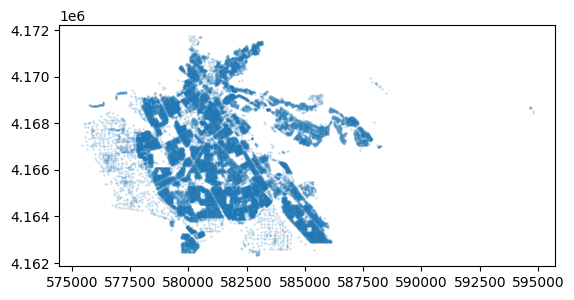

In [22]:
all_data.plot(markersize = 0.1, alpha = 0.5)